In [ ]:
# ── CELL 1 : Installs & Imports ─────────────────────────────────────────────
!pip install -q transformers torch scikit-learn matplotlib seaborn

import os, json, random, urllib.request, tarfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device     :", DEVICE)
if DEVICE.type == 'cuda':
    print("GPU name   :", torch.cuda.get_device_name(0))
    print("GPU memory :", round(
        torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")

Device     : cuda
GPU name   : Tesla T4
GPU memory : 15.6 GB


In [ ]:
# ── CELL 2 : Mount Drive & Folders ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/ICT4442_Project'

DRIVE = {
    'weights' : f'{BASE}/DistilBERT/weights',
    'history' : f'{BASE}/DistilBERT/history',
    'results' : f'{BASE}/DistilBERT/results',
}
for d in DRIVE.values():
    os.makedirs(d, exist_ok=True)

LOCAL = {
    'data'  : '/content/data',
    'plots' : '/content/plots/DistilBERT',
}
for d in LOCAL.values():
    os.makedirs(d, exist_ok=True)

# ── DistilBERT-specific constants ────────────────────────────────────────────
# MAX_LEN = 256 — DistilBERT uses WordPiece subword tokenization.
# A 256-word review expands to more subword tokens.
# Using 512 would cause OOM on free Colab T4 (16 GB).
# This is documented and justified in the report.
# MLP/CNN/BiLSTM used MAX_LEN=512 with a custom word-level tokenizer.
# DistilBERT uses its own tokenizer so the sequence lengths are
# not directly comparable — WordPiece tokens vs word tokens.

MAX_LEN    = 256
BATCH_SIZE = 16      # smaller than other models due to transformer size
MODEL_NAME = 'distilbert-base-uncased'

print(f"MAX_LEN    : {MAX_LEN}")
print(f"BATCH_SIZE : {BATCH_SIZE}")
print(f"Model      : {MODEL_NAME}")
print("Folders ready.")

Mounted at /content/drive
MAX_LEN    : 256
BATCH_SIZE : 16
Model      : distilbert-base-uncased
Folders ready.


In [ ]:
# ── CELL 3 : Download Dataset ────────────────────────────────────────────────
# DistilBERT does NOT use the shared Keras tokenizer from Drive.
# It has its own pretrained WordPiece tokenizer.
# So this notebook can run on any Google account independently.

DATA_PATH = '/content/data/aclImdb'

if not os.path.exists(DATA_PATH):
    print("Downloading IMDb dataset (~84 MB) to local /content ...")
    url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
    urllib.request.urlretrieve(url, '/content/data/aclImdb_v1.tar.gz')
    print("Extracting...")
    with tarfile.open('/content/data/aclImdb_v1.tar.gz', 'r:gz') as t:
        t.extractall('/content/data/')
    os.remove('/content/data/aclImdb_v1.tar.gz')
    print("Done.")
else:
    print("Dataset already local — skipping download.")

def load_split(split_dir):
    texts, labels = [], []
    for label_idx, sentiment in enumerate(['neg', 'pos']):
        folder = os.path.join(split_dir, sentiment)
        for fname in sorted(os.listdir(folder)):
            if fname.endswith('.txt'):
                with open(os.path.join(folder, fname),
                          encoding='utf-8') as f:
                    texts.append(f.read())
                labels.append(label_idx)
    return texts, labels

print("Loading splits...")
train_texts_full, train_labels_full = load_split(f'{DATA_PATH}/train')
test_texts,       test_labels_list  = load_split(f'{DATA_PATH}/test')

# ── Same stratified split as MLP, CNN, BiLSTM ────────────────────────────────
# SEED=42 and test_size=5000 must not change across any model
train_texts, val_texts, train_labels_list, val_labels_list = train_test_split(
    train_texts_full, train_labels_full,
    test_size=5000, random_state=SEED, stratify=train_labels_full
)

train_labels = np.array(train_labels_list)
val_labels   = np.array(val_labels_list)
test_labels  = np.array(test_labels_list)

print(f"Train : {len(train_texts):,}  "
      f"Val : {len(val_texts):,}  "
      f"Test : {len(test_texts):,}")
print(f"Class balance — Train pos: {train_labels.sum():,} / "
      f"neg: {(train_labels==0).sum():,}")

Extracting...


/tmp/ipykernel_1620/4200512366.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall('/content/data/')


Done.
Loading splits...
Train : 20,000  Val : 5,000  Test : 25,000
Class balance — Train pos: 10,000 / neg: 10,000


In [ ]:
# ── CELL 4 : Tokenizer + Dataset ─────────────────────────────────────────────
# Important: do NOT clean or stem text before passing to DistilBERT.
# The pretrained model expects natural text including punctuation.
# Heavy preprocessing would conflict with what the model learned
# during pretraining on raw text corpora.

print(f"Loading DistilBERT tokenizer ({MODEL_NAME})...")
tokenizer_bert = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print("Tokenizer loaded.")

class IMDbDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        print(f"  Tokenizing {len(texts):,} samples...")
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.float32)
        print(f"  Done. input_ids shape: {self.encodings['input_ids'].shape}")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids'     : self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'label'         : self.labels[idx]
        }

print("\nBuilding train dataset...")
train_dataset = IMDbDataset(
    train_texts, train_labels_list, tokenizer_bert, MAX_LEN
)
print("Building val dataset...")
val_dataset = IMDbDataset(
    val_texts, val_labels_list, tokenizer_bert, MAX_LEN
)
print("Building test dataset...")
test_dataset = IMDbDataset(
    test_texts, test_labels_list, tokenizer_bert, MAX_LEN
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")
print("All datasets built locally — not saved to Drive.")

Loading DistilBERT tokenizer (distilbert-base-uncased)...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded.

Building train dataset...
  Tokenizing 20,000 samples...
  Done. input_ids shape: torch.Size([20000, 256])
Building val dataset...
  Tokenizing 5,000 samples...
  Done. input_ids shape: torch.Size([5000, 256])
Building test dataset...
  Tokenizing 25,000 samples...
  Done. input_ids shape: torch.Size([25000, 256])

Train batches : 1250
Val batches   : 313
Test batches  : 1563
All datasets built locally — not saved to Drive.


In [ ]:
# ── CELL 5 : Load DistilBERT ─────────────────────────────────────────────────
# DistilBertForSequenceClassification adds a classification head
# on top of the [CLS] token output automatically.
# num_labels=1 → single sigmoid output → binary classification.
# The entire model (6 transformer layers + head) is fine-tuned.

print(f"Loading pretrained {MODEL_NAME}...")
bert_model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=1,
)
bert_model = bert_model.to(DEVICE)

total_params     = sum(p.numel() for p in bert_model.parameters())
trainable_params = sum(p.numel() for p in bert_model.parameters()
                       if p.requires_grad)
print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")
print(f"Model loaded to  : {DEVICE}")

Loading pretrained distilbert-base-uncased...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params     : 66,954,241
Trainable params : 66,954,241
Model loaded to  : cuda


In [ ]:
# ── CELL 6 : Train DistilBERT ────────────────────────────────────────────────
# Training decisions:
#   lr = 2e-5  — standard for BERT-family fine-tuning.
#                Much lower than MLP/CNN/BiLSTM (1e-3) to avoid
#                catastrophic forgetting of pretrained weights.
#   Linear warmup — lr increases from 0 to 2e-5 over first 10% of steps,
#                   then linearly decays to 0. Standard for Transformers.
#   Gradient clipping at 1.0 — prevents exploding gradients.
#   max_epochs = 5 — DistilBERT converges fast; more = overfit risk.
#   patience = 2 — tighter than other models (expensive per epoch).
#   batch_size = 16 — constrained by T4 GPU memory.
#   History saved after EVERY epoch — safe if session disconnects.

MAX_EPOCHS  = 5
LR          = 2e-5
WARMUP_FRAC = 0.1
CHECKPOINT  = f"{DRIVE['weights']}/distilbert_best.pt"
PATIENCE    = 2

optimizer = AdamW(bert_model.parameters(), lr=LR, weight_decay=0.01)

total_steps  = len(train_loader) * MAX_EPOCHS
warmup_steps = int(total_steps * WARMUP_FRAC)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

loss_fn = nn.BCEWithLogitsLoss()

history_data = {
    'model'         : 'DistilBERT',
    'max_len'       : MAX_LEN,
    'epochs_run'    : 0,
    'train_loss'    : [],
    'val_loss'      : [],
    'train_accuracy': [],
    'val_accuracy'  : [],
    'lr'            : [],
}

best_val_loss  = float('inf')
patience_count = 0

print(f"Total training steps : {total_steps}")
print(f"Warmup steps         : {warmup_steps}")
print(f"Patience             : {PATIENCE}")
print(f"Max epochs           : {MAX_EPOCHS}")
print("\nStarting training — ~30–45 min per epoch on free T4...\n")

for epoch in range(1, MAX_EPOCHS + 1):

    # ── Training phase ───────────────────────────────────────────────────────
    bert_model.train()
    train_loss_sum = 0.0
    train_correct  = 0
    train_total    = 0

    for batch_idx, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        labels_b  = batch['label'].to(DEVICE).unsqueeze(1)

        optimizer.zero_grad()
        outputs = bert_model(input_ids=input_ids,
                             attention_mask=attn_mask)
        logits  = outputs.logits
        loss    = loss_fn(logits, labels_b)
        loss.backward()

        # Gradient clipping — standard for Transformer fine-tuning
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        with torch.no_grad():
            preds = (torch.sigmoid(logits) >= 0.5).long().squeeze()
            train_correct  += (preds == labels_b.squeeze().long()).sum().item()
            train_total    += labels_b.size(0)
            train_loss_sum += loss.item()

        # Progress print every 100 steps
        if (batch_idx + 1) % 100 == 0:
            running_acc = train_correct / train_total
            print(f"  Epoch {epoch} | Step {batch_idx+1:>4}/{len(train_loader)} "
                  f"| loss={loss.item():.4f} "
                  f"| running_acc={running_acc:.4f}")

    train_loss = train_loss_sum / len(train_loader)
    train_acc  = train_correct  / train_total

    # ── Validation phase ─────────────────────────────────────────────────────
    bert_model.eval()
    val_loss_sum = 0.0
    val_correct  = 0
    val_total    = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attn_mask = batch['attention_mask'].to(DEVICE)
            labels_b  = batch['label'].to(DEVICE).unsqueeze(1)

            outputs  = bert_model(input_ids=input_ids,
                                  attention_mask=attn_mask)
            logits   = outputs.logits
            loss     = loss_fn(logits, labels_b)

            preds = (torch.sigmoid(logits) >= 0.5).long().squeeze()
            val_correct  += (preds == labels_b.squeeze().long()).sum().item()
            val_total    += labels_b.size(0)
            val_loss_sum += loss.item()

    val_loss = val_loss_sum / len(val_loader)
    val_acc  = val_correct  / val_total
    cur_lr   = scheduler.get_last_lr()[0]

    # ── Log epoch ────────────────────────────────────────────────────────────
    history_data['train_loss'].append(train_loss)
    history_data['val_loss'].append(val_loss)
    history_data['train_accuracy'].append(train_acc)
    history_data['val_accuracy'].append(val_acc)
    history_data['lr'].append(cur_lr)
    history_data['epochs_run'] = epoch

    print(f"\n── Epoch {epoch}/{MAX_EPOCHS} ─────────────────────────────")
    print(f"  train_loss = {train_loss:.4f} | train_acc = {train_acc:.4f}")
    print(f"  val_loss   = {val_loss:.4f}   | val_acc   = {val_acc:.4f}")
    print(f"  lr         = {cur_lr:.2e}")

    # Save history after every epoch — safe against disconnection
    with open(f"{DRIVE['history']}/distilbert_history.json", 'w') as f:
        json.dump(history_data, f, indent=2)
    print(f"  History saved to Drive.")

    # ── Checkpoint + early stopping ──────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_count = 0
        torch.save(bert_model.state_dict(), CHECKPOINT)
        print(f"  ✓ New best — model saved (val_loss={best_val_loss:.4f})")
    else:
        patience_count += 1
        print(f"  No improvement. Patience {patience_count}/{PATIENCE}")
        if patience_count >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

print("\nTraining complete.")
print(f"Best val_loss : {best_val_loss:.4f}")

# Restore best weights
bert_model.load_state_dict(
    torch.load(CHECKPOINT, map_location=DEVICE)
)
print("Best weights restored from Drive checkpoint.")

Total training steps : 6250
Warmup steps         : 625
Patience             : 2
Max epochs           : 5

Starting training — ~30–45 min per epoch on free T4...

  Epoch 1 | Step  100/1250 | loss=0.6945 | running_acc=0.5312
  Epoch 1 | Step  200/1250 | loss=0.5702 | running_acc=0.6503
  Epoch 1 | Step  300/1250 | loss=0.4008 | running_acc=0.7192
  Epoch 1 | Step  400/1250 | loss=0.2797 | running_acc=0.7588
  Epoch 1 | Step  500/1250 | loss=0.1865 | running_acc=0.7780
  Epoch 1 | Step  600/1250 | loss=0.3549 | running_acc=0.7955
  Epoch 1 | Step  700/1250 | loss=0.4179 | running_acc=0.8065
  Epoch 1 | Step  800/1250 | loss=0.1471 | running_acc=0.8161
  Epoch 1 | Step  900/1250 | loss=0.4399 | running_acc=0.8240
  Epoch 1 | Step 1000/1250 | loss=0.1329 | running_acc=0.8315
  Epoch 1 | Step 1100/1250 | loss=0.2043 | running_acc=0.8366
  Epoch 1 | Step 1200/1250 | loss=0.2673 | running_acc=0.8414

── Epoch 1/5 ─────────────────────────────
  train_loss = 0.3496 | train_acc = 0.8439
  val_l

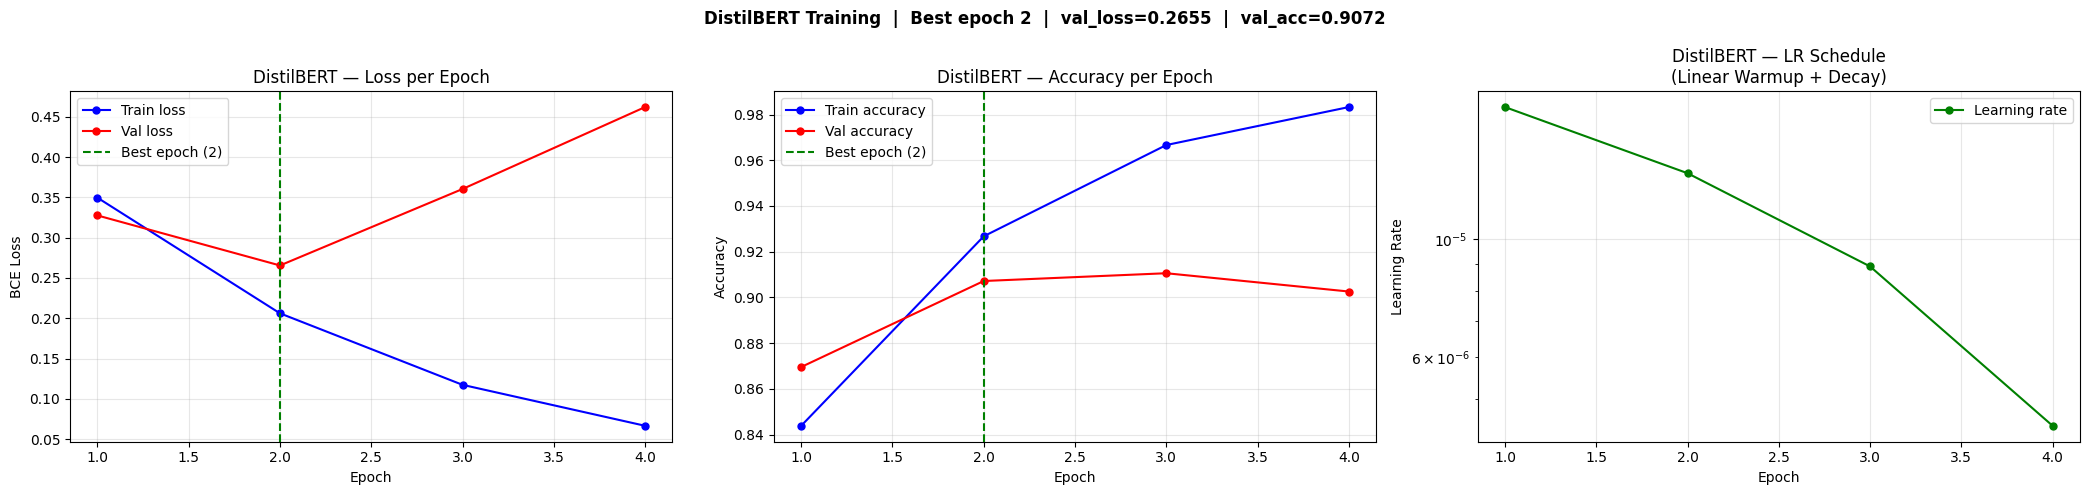

Training curves saved locally.


In [ ]:
# ── CELL 7 : Training Curves ─────────────────────────────────────────────────
# To reload without retraining:
# with open(f"{DRIVE['history']}/distilbert_history.json") as f:
#     history_data = json.load(f)

epochs = range(1, history_data['epochs_run'] + 1)
best_e = np.argmin(history_data['val_loss']) + 1

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# Loss
axes[0].plot(epochs, history_data['train_loss'], 'b-o',
             markersize=5, label='Train loss')
axes[0].plot(epochs, history_data['val_loss'],   'r-o',
             markersize=5, label='Val loss')
axes[0].axvline(best_e, color='green', linestyle='--',
                label=f'Best epoch ({best_e})')
axes[0].set_title('DistilBERT — Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs, history_data['train_accuracy'], 'b-o',
             markersize=5, label='Train accuracy')
axes[1].plot(epochs, history_data['val_accuracy'],   'r-o',
             markersize=5, label='Val accuracy')
axes[1].axvline(best_e, color='green', linestyle='--',
                label=f'Best epoch ({best_e})')
axes[1].set_title('DistilBERT — Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Learning rate — shows warmup then decay
axes[2].plot(epochs, history_data['lr'], 'g-o',
             markersize=5, label='Learning rate')
axes[2].set_title('DistilBERT — LR Schedule\n(Linear Warmup + Decay)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_yscale('log')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle(
    f"DistilBERT Training  |  Best epoch {best_e}  |  "
    f"val_loss={history_data['val_loss'][best_e-1]:.4f}  |  "
    f"val_acc={history_data['val_accuracy'][best_e-1]:.4f}",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f"{LOCAL['plots']}/01_distilbert_training_curves.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved locally.")

In [ ]:
# ── CELL 8 : Prediction Helper ───────────────────────────────────────────────
# Defined as a function so Cell 9 (val) and Cell 10 (test) can both use it
# without repeating code.

def get_probs_preds(model, loader, device):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attn_mask = batch['attention_mask'].to(device)
            logits    = model(input_ids=input_ids,
                              attention_mask=attn_mask).logits
            probs     = torch.sigmoid(logits).squeeze().cpu().numpy()
            # Handle edge case where batch size = 1
            if probs.ndim == 0:
                probs = np.array([probs.item()])
            all_probs.extend(probs.tolist())
    all_probs = np.array(all_probs)
    all_preds = (all_probs >= 0.5).astype(int)
    return all_probs, all_preds

print("Prediction helper defined.")

Prediction helper defined.


Running validation predictions...
── Validation Metrics ──────────────────────
  accuracy    : 0.9072
  precision   : 0.9082
  recall      : 0.9060
  f1          : 0.9071
  auc         : 0.9653

              precision    recall  f1-score   support

    Negative       0.91      0.91      0.91      2500
    Positive       0.91      0.91      0.91      2500

    accuracy                           0.91      5000
   macro avg       0.91      0.91      0.91      5000
weighted avg       0.91      0.91      0.91      5000



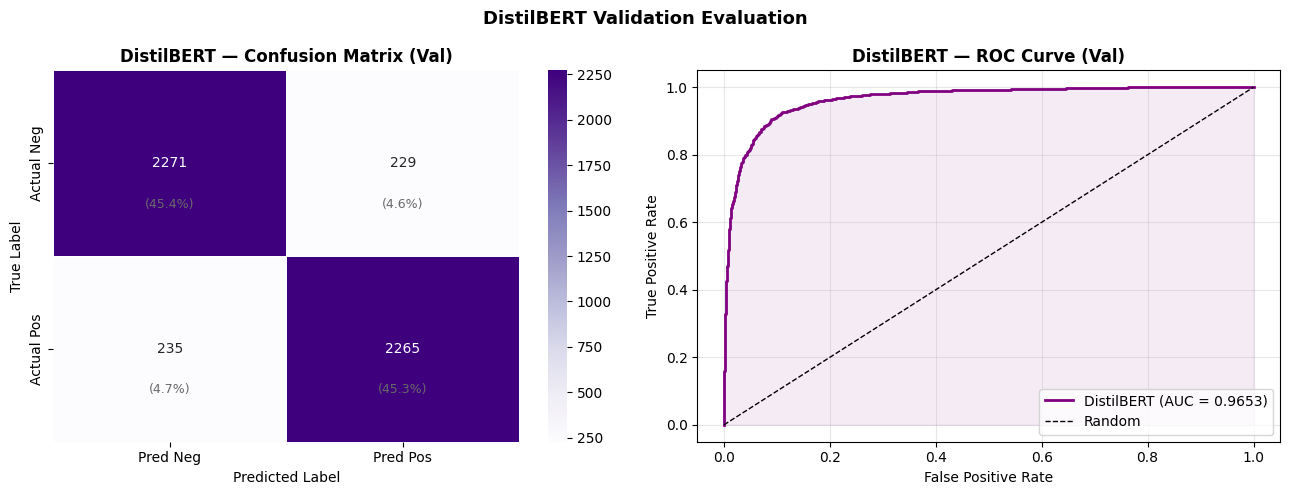

Val results saved to Drive.


In [ ]:
# ── CELL 9 : Validation Evaluation ───────────────────────────────────────────
# To reload saved results without retraining:
# val_probs = np.load(f"{DRIVE['results']}/val_probs.npy")
# val_preds = np.load(f"{DRIVE['results']}/val_preds.npy")
# with open(f"{DRIVE['results']}/roc_val.json") as f:
#     roc_val = json.load(f)

print("Running validation predictions...")
val_probs, val_preds = get_probs_preds(bert_model, val_loader, DEVICE)

val_metrics = {
    'model'    : 'DistilBERT',
    'split'    : 'validation',
    'max_len'  : MAX_LEN,
    'accuracy' : float(accuracy_score(val_labels,  val_preds)),
    'precision': float(precision_score(val_labels, val_preds)),
    'recall'   : float(recall_score(val_labels,    val_preds)),
    'f1'       : float(f1_score(val_labels,        val_preds)),
    'auc'      : float(roc_auc_score(val_labels,   val_probs)),
}

print("── Validation Metrics ──────────────────────")
for k, v in val_metrics.items():
    if k not in ('model', 'split', 'max_len'):
        print(f"  {k:12s}: {v:.4f}")
print()
print(classification_report(
    val_labels, val_preds,
    target_names=['Negative', 'Positive']
))

fpr, tpr, _ = roc_curve(val_labels, val_probs)
roc_val = {
    'fpr': fpr.tolist(),
    'tpr': tpr.tolist(),
    'auc': val_metrics['auc']
}

np.save(f"{DRIVE['results']}/val_probs.npy", val_probs)
np.save(f"{DRIVE['results']}/val_preds.npy", val_preds)
with open(f"{DRIVE['results']}/val_metrics.json", 'w') as f:
    json.dump(val_metrics, f, indent=2)
with open(f"{DRIVE['results']}/roc_val.json", 'w') as f:
    json.dump(roc_val, f)

# Confusion matrix + ROC
cm = confusion_matrix(val_labels, val_preds)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
    xticklabels=['Pred Neg', 'Pred Pos'],
    yticklabels=['Actual Neg', 'Actual Pos'],
    linewidths=0.5
)
for i in range(2):
    for j in range(2):
        axes[0].text(
            j + 0.5, i + 0.72,
            f"({cm[i,j] / cm.sum() * 100:.1f}%)",
            ha='center', va='center',
            fontsize=9, color='dimgray'
        )
axes[0].set_title('DistilBERT — Confusion Matrix (Val)', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

axes[1].plot(roc_val['fpr'], roc_val['tpr'],
             color='purple', lw=2,
             label=f"DistilBERT (AUC = {roc_val['auc']:.4f})")
axes[1].plot([0,1], [0,1], 'k--', lw=1, label='Random')
axes[1].fill_between(roc_val['fpr'], roc_val['tpr'],
                     alpha=0.08, color='purple')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('DistilBERT — ROC Curve (Val)', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.suptitle('DistilBERT Validation Evaluation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{LOCAL['plots']}/02_distilbert_val_cm_roc.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Val results saved to Drive.")

Running test predictions...
── TEST RESULTS ───────────────────────────
  accuracy    : 0.9071
  precision   : 0.9085
  recall      : 0.9054
  f1          : 0.9069
  auc         : 0.9691

              precision    recall  f1-score   support

    Negative       0.91      0.91      0.91     12500
    Positive       0.91      0.91      0.91     12500

    accuracy                           0.91     25000
   macro avg       0.91      0.91      0.91     25000
weighted avg       0.91      0.91      0.91     25000



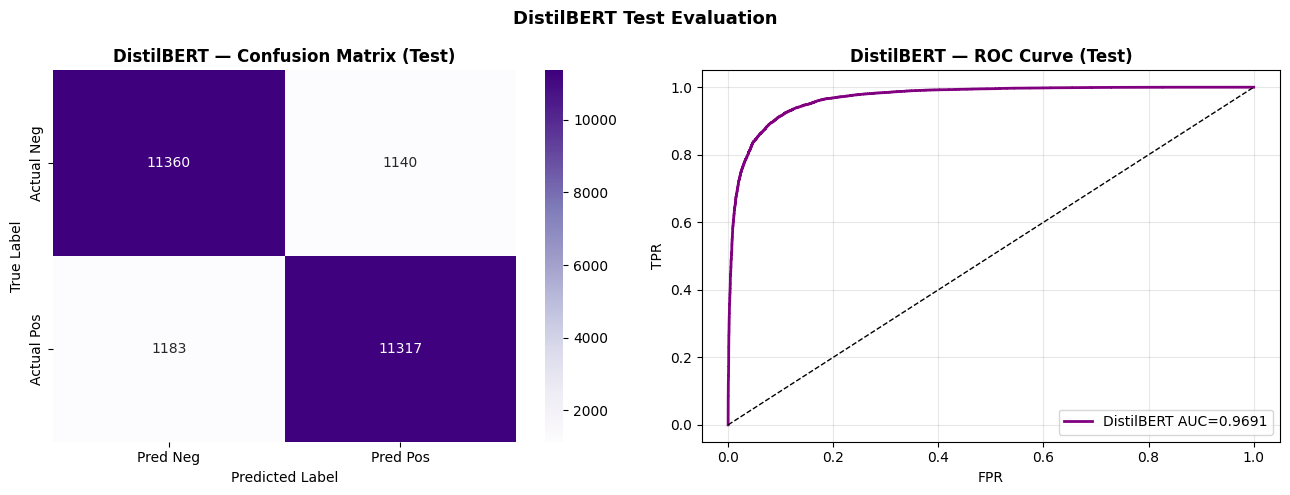

All test results saved to Drive.


In [ ]:
# ── CELL 10 : TEST SET EVALUATION ────────────────────────────────────────────
# ╔══════════════════════════════════════════════════════════════════╗
# ║  ONLY RUN AFTER ALL FOUR MODELS ARE FULLY FINALIZED.            ║
# ║  BiLSTM must also be finalized before running this cell.        ║
# ║  The test set must not influence any further decisions.         ║
# ╚══════════════════════════════════════════════════════════════════╝

print("Running test predictions...")
test_probs, test_preds = get_probs_preds(bert_model, test_loader, DEVICE)

test_metrics = {
    'model'    : 'DistilBERT',
    'split'    : 'test',
    'max_len'  : MAX_LEN,
    'accuracy' : float(accuracy_score(test_labels,  test_preds)),
    'precision': float(precision_score(test_labels, test_preds)),
    'recall'   : float(recall_score(test_labels,    test_preds)),
    'f1'       : float(f1_score(test_labels,        test_preds)),
    'auc'      : float(roc_auc_score(test_labels,   test_probs)),
}

print("── TEST RESULTS ───────────────────────────")
for k, v in test_metrics.items():
    if k not in ('model', 'split', 'max_len'):
        print(f"  {k:12s}: {v:.4f}")
print()
print(classification_report(
    test_labels, test_preds,
    target_names=['Negative', 'Positive']
))

fpr_t, tpr_t, _ = roc_curve(test_labels, test_probs)
roc_test = {
    'fpr': fpr_t.tolist(),
    'tpr': tpr_t.tolist(),
    'auc': test_metrics['auc']
}

np.save(f"{DRIVE['results']}/test_probs.npy", test_probs)
np.save(f"{DRIVE['results']}/test_preds.npy", test_preds)
with open(f"{DRIVE['results']}/test_metrics.json", 'w') as f:
    json.dump(test_metrics, f, indent=2)
with open(f"{DRIVE['results']}/roc_test.json", 'w') as f:
    json.dump(roc_test, f)

# Confusion matrix + ROC
cm_t = confusion_matrix(test_labels, test_preds)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(
    cm_t, annot=True, fmt='d', cmap='Purples', ax=axes[0],
    xticklabels=['Pred Neg', 'Pred Pos'],
    yticklabels=['Actual Neg', 'Actual Pos']
)
axes[0].set_title('DistilBERT — Confusion Matrix (Test)', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

axes[1].plot(fpr_t, tpr_t, color='purple', lw=2,
             label=f"DistilBERT AUC={test_metrics['auc']:.4f}")
axes[1].plot([0,1], [0,1], 'k--', lw=1)
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('DistilBERT — ROC Curve (Test)', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('DistilBERT Test Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{LOCAL['plots']}/03_distilbert_test_cm_roc.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("All test results saved to Drive.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os, json

BASE      = '/content/drive/MyDrive/ICT4442_Project'
HIST_PATH = f'{BASE}/DistilBERT/history/distilbert_history.json'
CKPT_PATH = f'{BASE}/DistilBERT/weights/distilbert_best.pt'

print("History file exists :", os.path.exists(HIST_PATH))
print("Checkpoint exists   :", os.path.exists(CKPT_PATH))

if os.path.exists(HIST_PATH):
    with open(HIST_PATH) as f:
        h = json.load(f)
    print(f"Epochs completed    : {h['epochs_run']}")
    if h['val_loss']:
        print(f"Best val_loss       : {min(h['val_loss']):.4f}")
        print(f"Best val_acc        : {max(h['val_accuracy']):.4f}")
else:
    print("No history found — will need full restart.")

Mounted at /content/drive
History file exists : False
Checkpoint exists   : False
No history found — will need full restart.


In [ ]:
import torch
print("CUDA available :", torch.cuda.is_available())
print("Device         :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU — DO NOT PROCEED")

CUDA available : True
Device         : Tesla T4
